 # Laboratorio 7 Kmeans



### 1. Importar Librerías Necesarias y Configurar Rutas

In [4]:
import os
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/Datasets/Stanford_dogs_unlabeled'

train_dir = os.path.join(ruta_dataset, 'train')
test_dir = os.path.join(ruta_dataset, 'test')

# Dimensiones a las que se redimensionarán las imágenes
IMG_WIDTH = 64
IMG_HEIGHT = 64

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Función para Cargar y Preprocesar Imágenes

In [5]:
def procesar_imagen(imagen_path, target_size=(IMG_WIDTH, IMG_HEIGHT)):
    try:
        img = Image.open(imagen_path).convert('RGB')  # Abrir y convertir a RGB
        img = img.resize(target_size)                 # Redimensionar
        img_array = np.array(img)                     # Convertir a array NumPy
        img_array = img_array / 255.0                 # Normalizar píxeles a [0, 1]
        return img_array.flatten()                    # Aplanar la imagen en un vector
    except Exception as e:
        print(f"Error al cargar o procesar la imagen {imagen_path}: {e}")
        return None

def cargar_imagenes(directorio, num_images=None):
    images_data = []
    image_filenames = [os.path.join(directorio, f) for f in os.listdir(directorio)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if num_images: # Limitar el número de imágenes si se especifica
        image_filenames = image_filenames[:num_images]

    print(f"Cargando {len(image_filenames)} imágenes de {directorio}...")
    for i, image_path in enumerate(image_filenames):
        processed_img = procesar_imagen(image_path)
        if processed_img is not None:
            images_data.append(processed_img)
        if (i + 1) % 1000 == 0:
            print(f"{i + 1} imágenes procesadas.")

    return np.array(images_data)

### 3. Cargar el Dataset (Subset de Entrenamiento)

In [6]:
X_train = cargar_imagenes(train_dir)

if X_train.shape[0] > 0:
    print(f"Shape final del dataset de entrenamiento cargado: {X_train.shape}")
    print("Las imágenes han sido aplanadas a vectores de tamaño", IMG_WIDTH * IMG_HEIGHT * 3)
else:
    print("No se cargaron imágenes. Verifica la ruta del dataset y si hay imágenes en la carpeta 'train'.")

Cargando 12000 imágenes de /content/drive/MyDrive/Colab Notebooks/Datasets/Stanford_dogs_unlabeled/train...
1000 imágenes procesadas.
2000 imágenes procesadas.
3000 imágenes procesadas.
4000 imágenes procesadas.
5000 imágenes procesadas.
6000 imágenes procesadas.
7000 imágenes procesadas.
8000 imágenes procesadas.
9000 imágenes procesadas.
10000 imágenes procesadas.
11000 imágenes procesadas.
12000 imágenes procesadas.
Shape final del dataset de entrenamiento cargado: (12000, 12288)
Las imágenes han sido aplanadas a vectores de tamaño 12288


In [7]:
print(X_train.data.shape)

(12000, 12288)


### 4. Aplicación de Kmeans

In [33]:
from sklearn.cluster import KMeans

k = 20

kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)


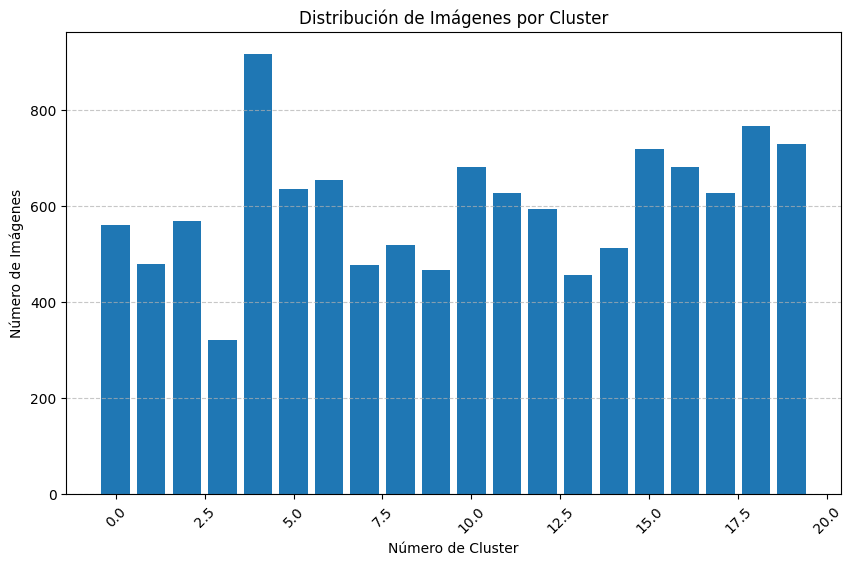

In [34]:
import pandas as pd

# Obtener el cluster asignado a cada imagen
cluster_labels = np.argmin(X_digits_dist, axis=1)

# Contar las ocurrencias de cada cluster
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.title('Distribución de Imágenes por Cluster')
plt.xlabel('Número de Cluster')
plt.ylabel('Número de Imágenes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Encontrando número optimo de grupos

In [ ]:
from sklearn.metrics import silhouette_score

# Define un rango de valores para k a explorar
k_range = range(20, 100, 20)
silhouette_scores = []
kmeans_per_k = []

for k in k_range:
    print(f"Calculando K-Means para k={k}...")
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10) # Añadir n_init para evitar warnings
    kmeans_model.fit(X_train)
    silhouette_scores.append(silhouette_score(X_train, kmeans_model.labels_))
    kmeans_per_k.append(kmeans_model)

# Imprimir los scores obtenidos
for i, k_val in enumerate(k_range):
    print(f"Silhouette Score para k={k_val}: {silhouette_scores[i]:.4f}")

Calculando K-Means para k=20...
Calculando K-Means para k=40...
Calculando K-Means para k=60...
Calculando K-Means para k=80...
Silhouette Score para k=20: 0.0204
Silhouette Score para k=40: 0.0129
Silhouette Score para k=60: 0.0103
Silhouette Score para k=80: 0.0089


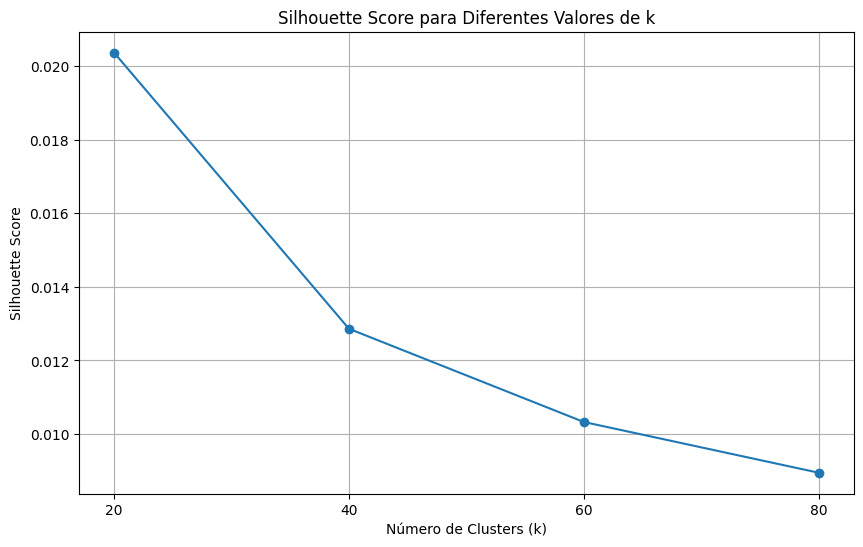

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score para Diferentes Valores de k')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range) # Asegura que todos los valores de k se muestren en el eje x
plt.grid(True)
plt.show()

### 5. Visualizar las Imágenes Representativas de Cada Cluster

In [35]:
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]

In [36]:
print(X_representative_digits.shape)
print(X_representative_digits)

(20, 12288)
[[0.32156863 0.29019608 0.23921569 ... 0.31372549 0.23137255 0.2       ]
 [0.40784314 0.36078431 0.29411765 ... 0.44705882 0.39215686 0.34901961]
 [0.69019608 0.76470588 0.46666667 ... 0.20784314 0.20784314 0.20784314]
 ...
 [0.63529412 0.63921569 0.61176471 ... 0.50980392 0.51372549 0.36078431]
 [0.58823529 0.45882353 0.3372549  ... 0.51372549 0.36470588 0.29019608]
 [0.49019608 0.47843137 0.45490196 ... 0.52941176 0.52156863 0.47058824]]


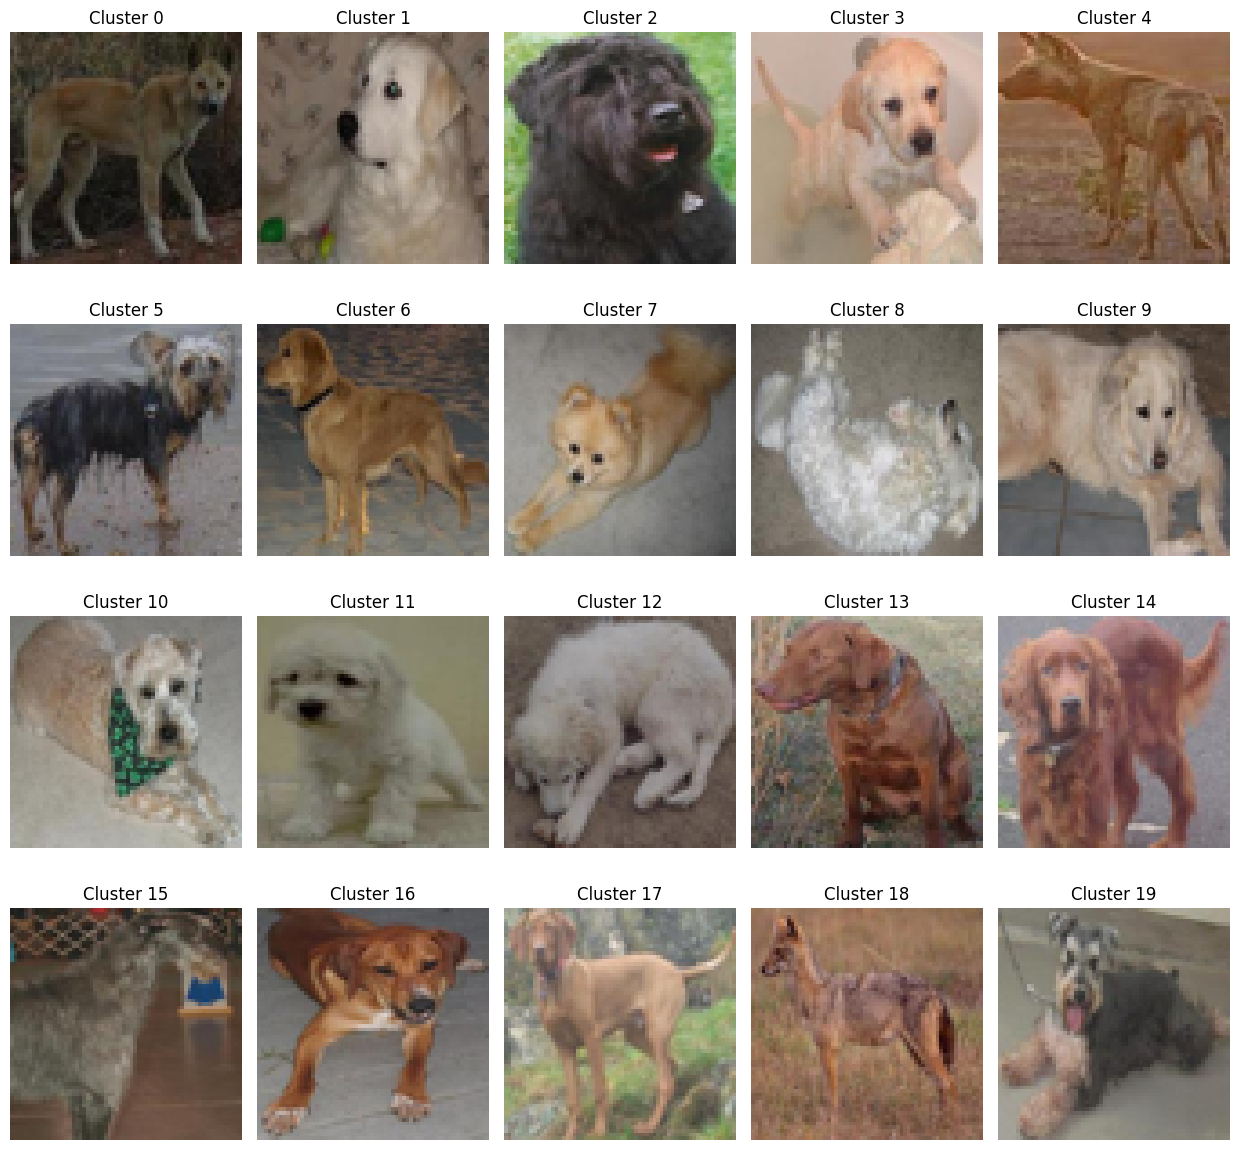

In [38]:
n_clusters = k

# Determinar un número adecuado de columnas y filas para la visualización
# Por ejemplo, un máximo de 5 columnas para evitar que sea demasiado ancho
num_cols = min(n_clusters, 5)
num_rows = (n_clusters + num_cols - 1) // num_cols # Calcular filas necesarias

# Ajustar el tamaño de la figura para que sea proporcional al número de imágenes y su disposición
# Asumiendo un tamaño por imagen de ~2x2.5 pulgadas para cada subplot
plt.figure(figsize=(num_cols * 2.5, num_rows * 3))

for index, representative_image_flat in enumerate(X_representative_digits):
    plt.subplot(num_rows, num_cols, index + 1) # Crear una cuadrícula de subplots
    # Reconstruir la imagen a su forma original
    image = representative_image_flat.reshape(IMG_HEIGHT, IMG_WIDTH, 3)
    plt.imshow(image)
    plt.title(f"Cluster {index}") # Añadir el título del cluster
    plt.axis('off') # Ocultar los ejes para una mejor visualización

plt.tight_layout() # Ajustar el layout para evitar superposiciones
plt.show()

### 6. Interpretación Manual de los Clusters Representativos

Se anotaron manualmente las etiquetas a cada cluster en un diccionario.

In [42]:
cluster_descriptions = {
    0: 'Pelaje_oscuro Fondo_oscuro Perro_parado',
    1: 'Pelaje_claro Orejon Perro_sentado',
    2: 'Pelaje_oscuro Fondo_verde',
    3: 'Pelaje_claro Perro_pequeño',
    4: 'Salvaje Fondo_de_tierra Perro_parado',
    5: 'Perro_pequeño Pelaje_largo Perro_parado',
    6: 'Perro_grande Pelaje_cafe Perro_parado',
    7: 'Perro_pequeño Fondo_blanco Perro_echado',
    8: 'Pelaje_blanco Perro_echado',
    9: 'Perro_sentado Pelaje_claro',
    10: 'Perro_mediano Pelaje_claro Perro_sentado',
    11: 'Perro_pequeño Cachorro Pelaje_claro',
    12: 'Pelaje_claro Perro_echado Fondo_de_tierra',
    13: 'Pelaje_marron Fondo_natural Fondo_verde',
    14: 'Pelaje_marron Fondo_gris',
    15: 'Pelaje_gris Fondo_marron',
    16: 'Pelaje_marron Perro_sentado Fondo_claro',
    17: 'Fondo_verde Perro_parado Pelaje_marron',
    18: 'Camuflado Fondo_natural Perro_parado',
    19: 'Pelaje_gris Perro_mediano Perro_sentado'
}

In [43]:
import pandas as pd
import os

# Asumiendo que `train_dir` y `cluster_labels` están definidos en celdas anteriores
# Primero, obtenemos la lista de rutas de todas las imágenes en el directorio de entrenamiento
image_filenames_full = [os.path.join(train_dir, f) for f in os.listdir(train_dir)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Asegurarse de que el número de nombres de archivo coincida con el número de imágenes en X_train
# Esto es importante si el dataset original fue limitado en 'cargar_imagenes'
# Si `X_train` tiene 12000 elementos, y `image_filenames_full` tiene más, tomamos los primeros 12000.
image_filenames_loaded = image_filenames_full[:X_train.shape[0]]

# Crear el DataFrame
image_df = pd.DataFrame({
    'image_path': image_filenames_loaded,
    'cluster_label': cluster_labels,
    'description': [cluster_descriptions[label] for label in cluster_labels]
})

print(f"DataFrame 'image_df' creado con {len(image_df)} entradas.")
display(image_df.head())

DataFrame 'image_df' creado con 12000 entradas.


,image_path,cluster_label,description
0,/content/drive/MyDrive/Colab Notebooks/Dataset...,16,Pelaje_marron Perro_sentado Fondo_claro
1,/content/drive/MyDrive/Colab Notebooks/Dataset...,6,Perro_grande Pelaje_cafe Perro_parado
2,/content/drive/MyDrive/Colab Notebooks/Dataset...,18,Camuflado Fondo_natural Perro_parado
3,/content/drive/MyDrive/Colab Notebooks/Dataset...,11,Perro_pequeño Cachorro Pelaje_claro
4,/content/drive/MyDrive/Colab Notebooks/Dataset...,13,Pelaje_marron Fondo_natural Fondo_verde


### 8. Visualización Aleatoria de Imágenes por Cluster para Validación

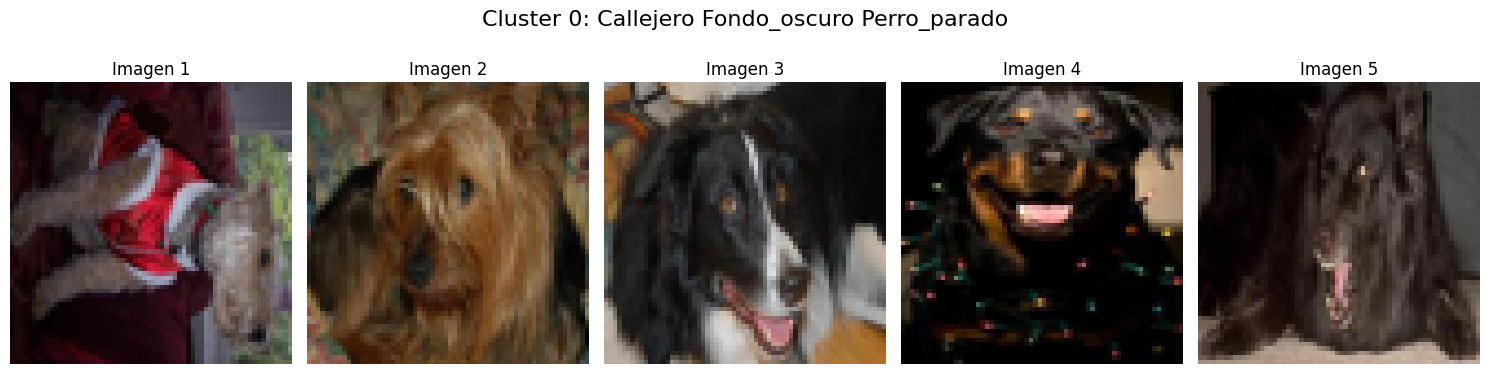

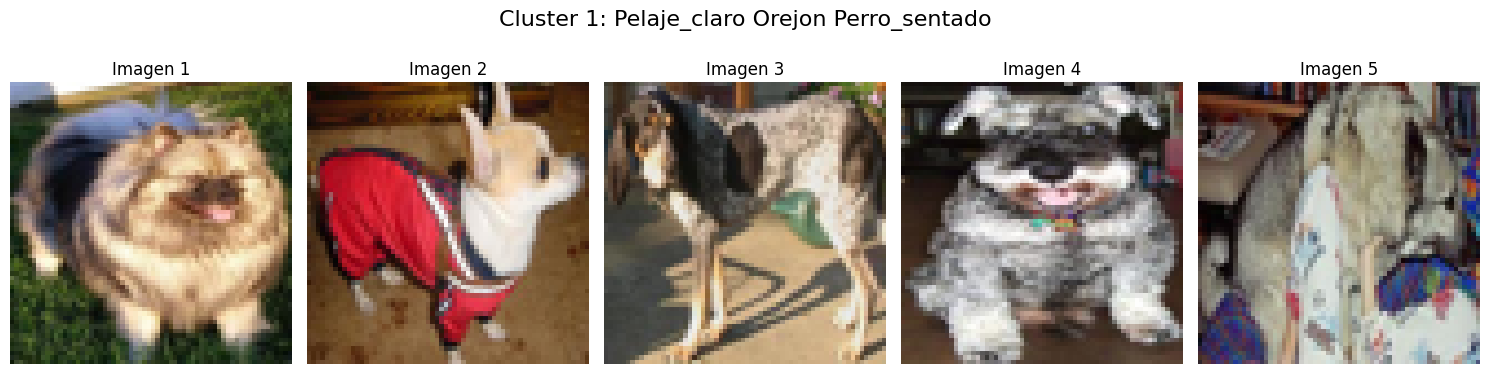

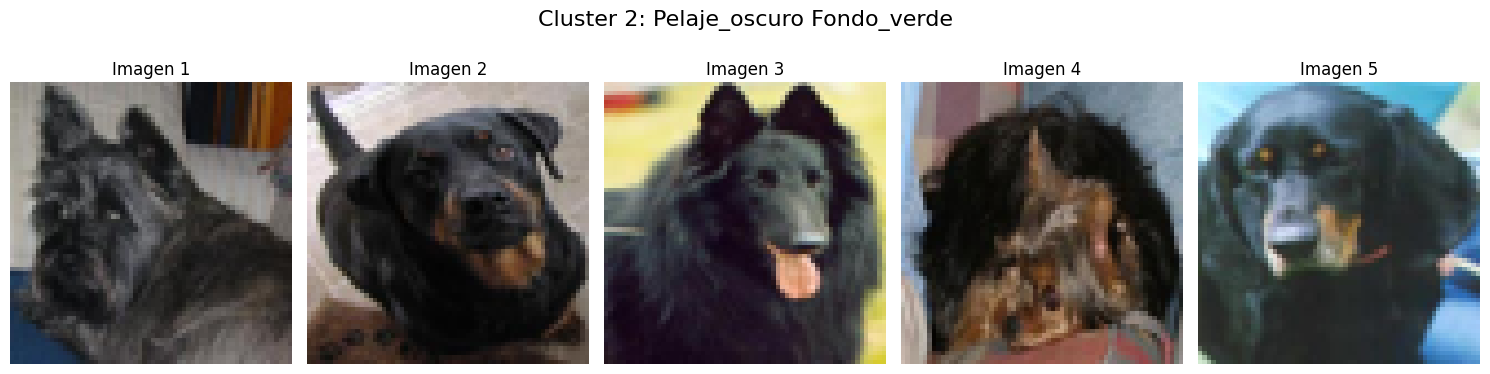

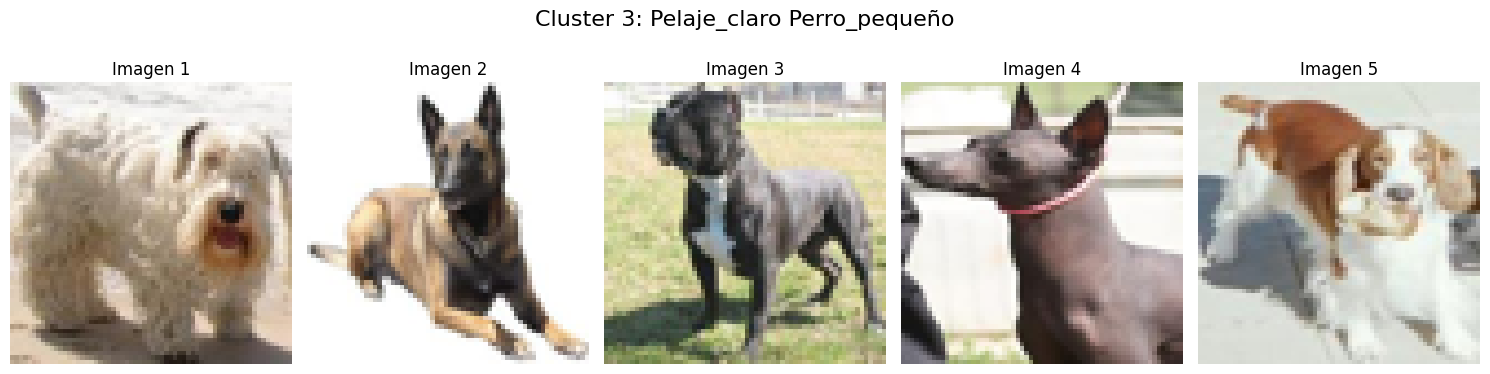

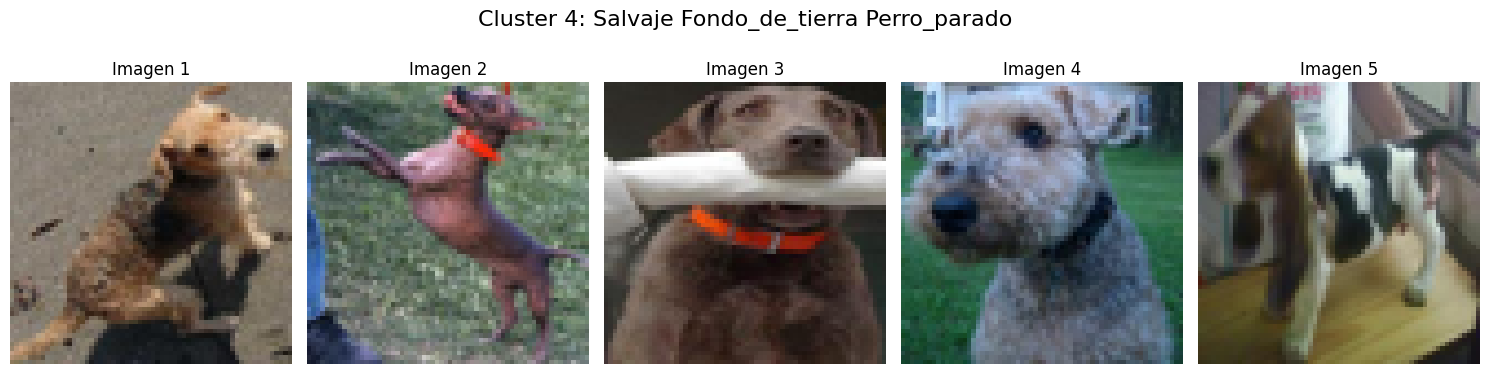

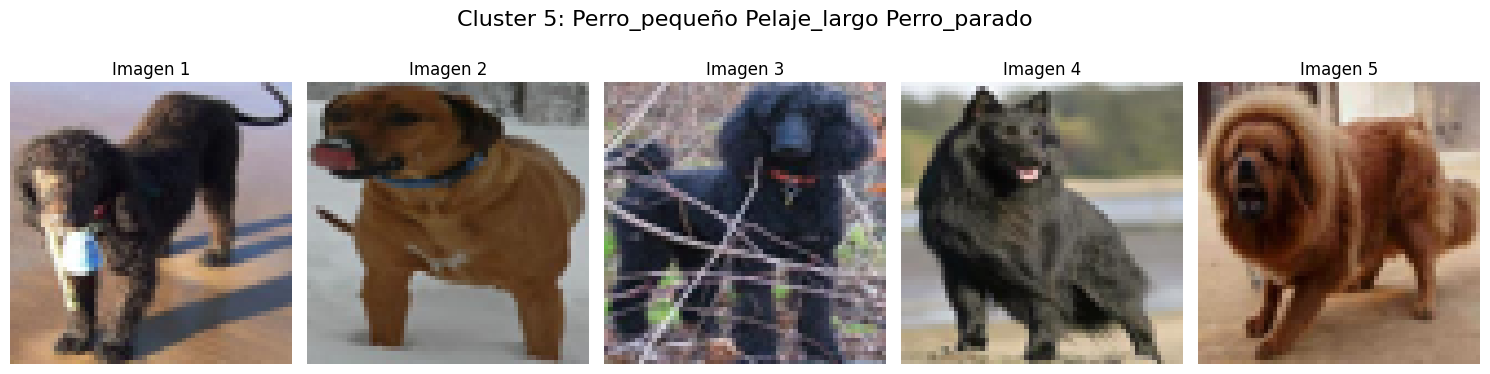

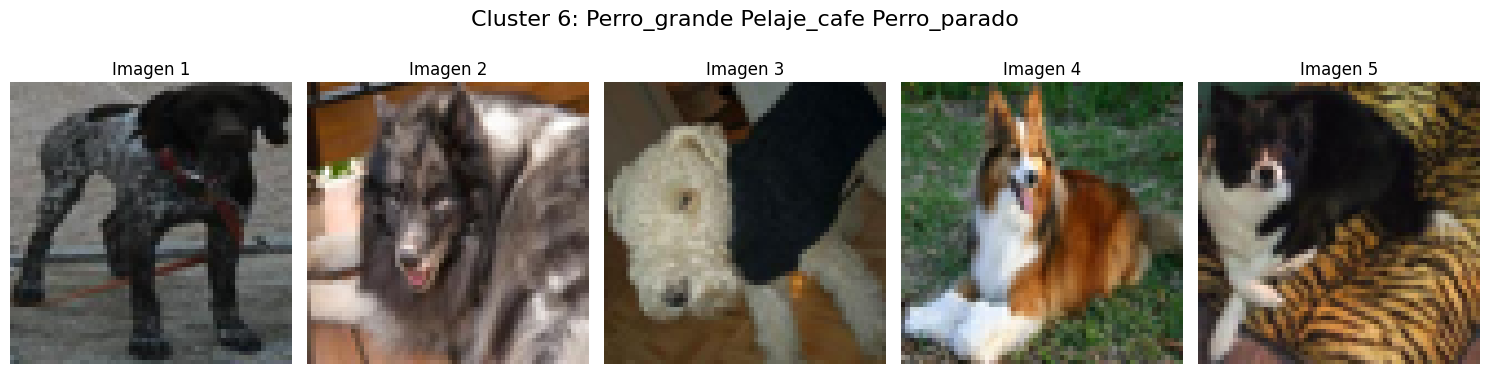

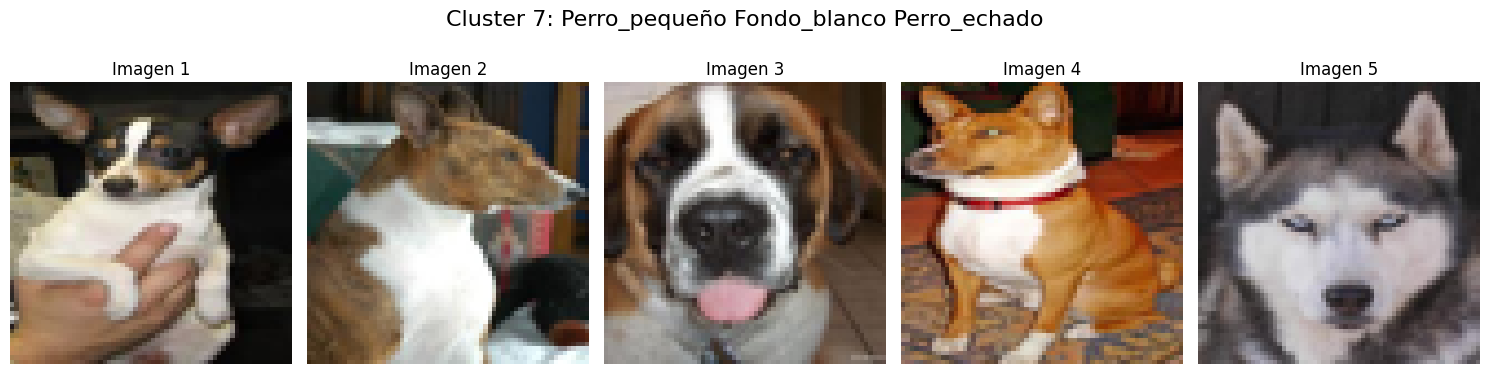

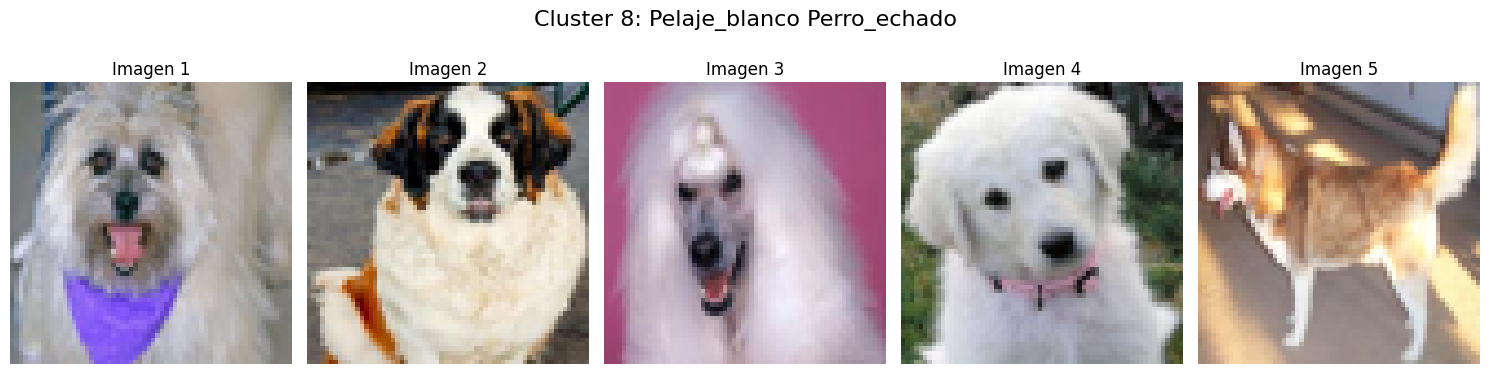

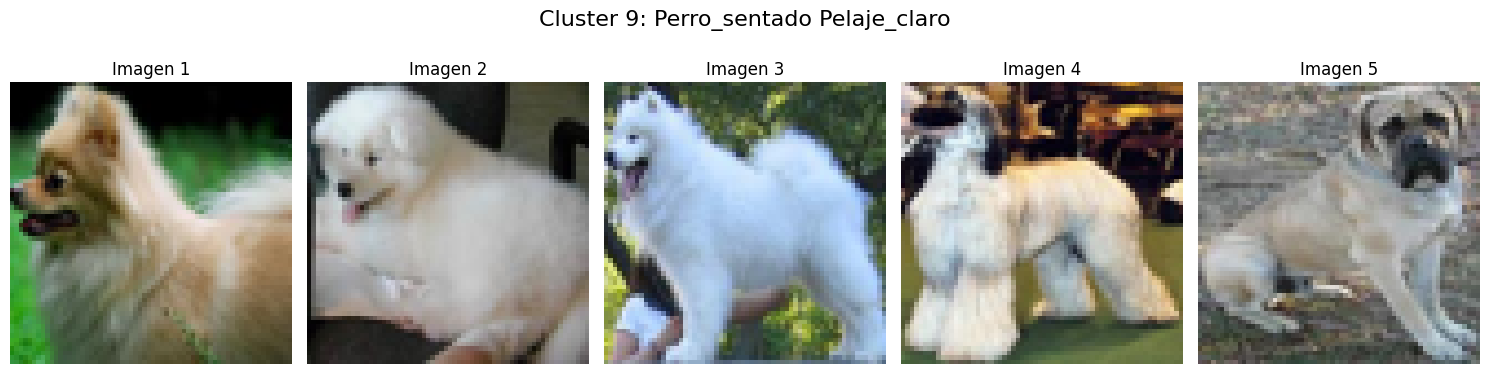

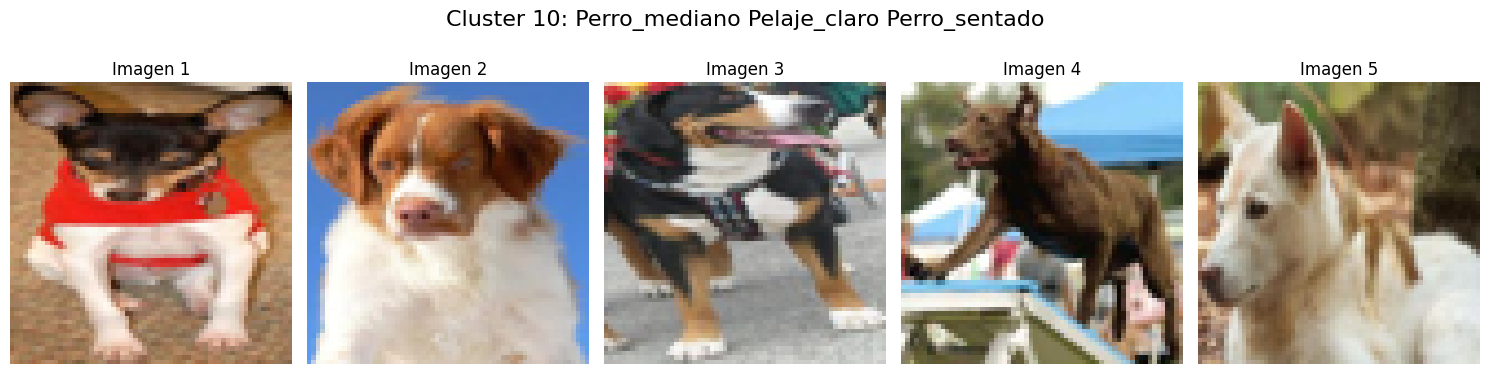

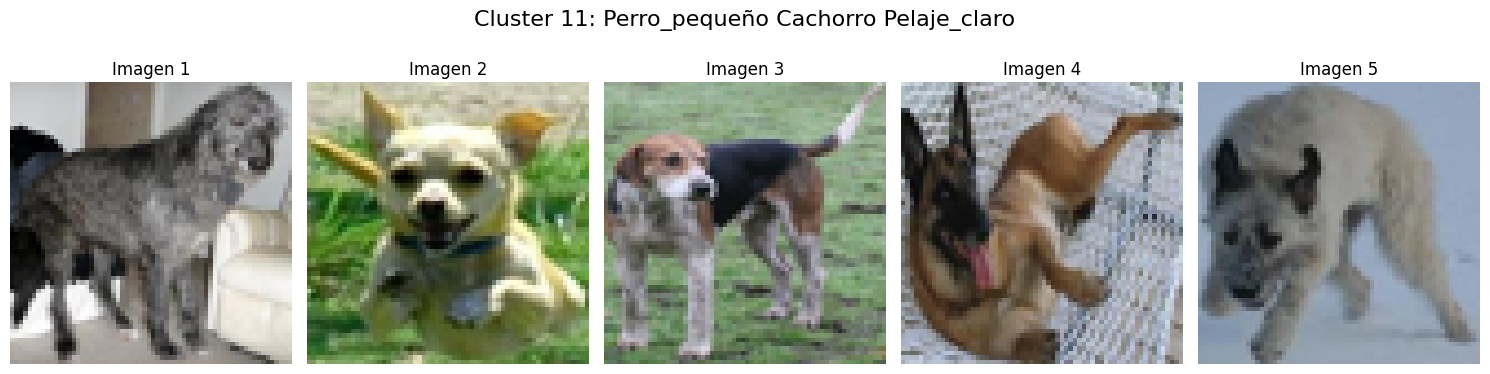

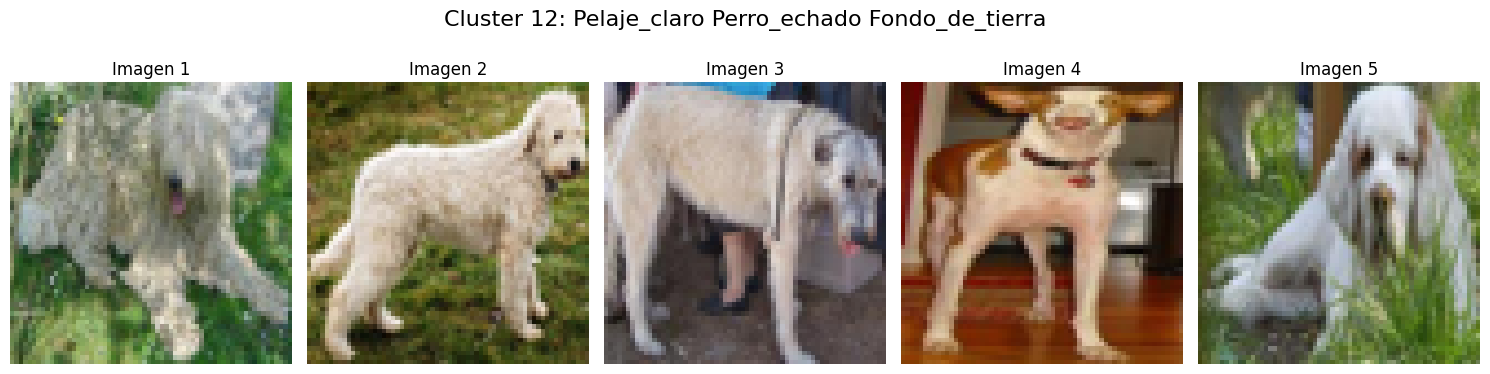

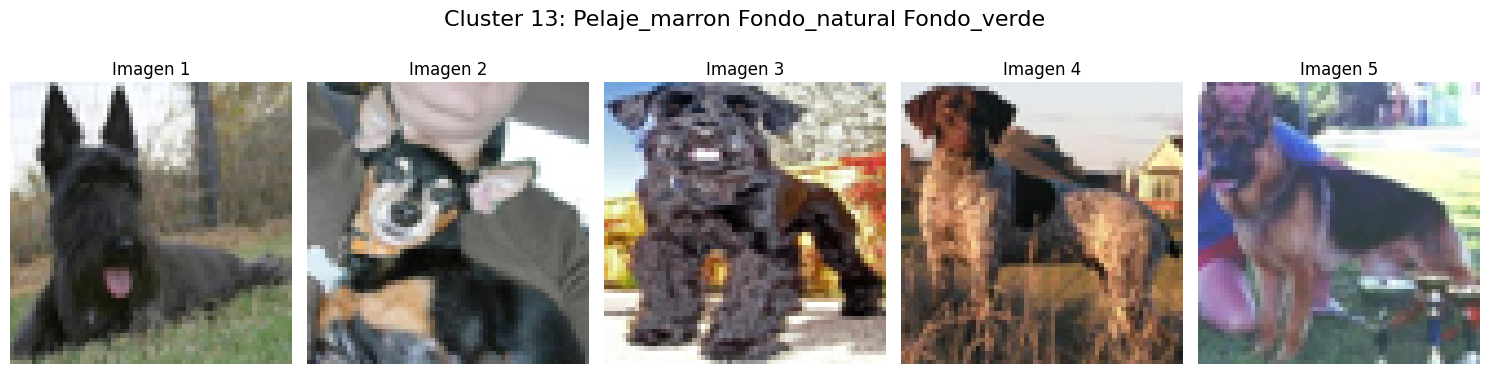

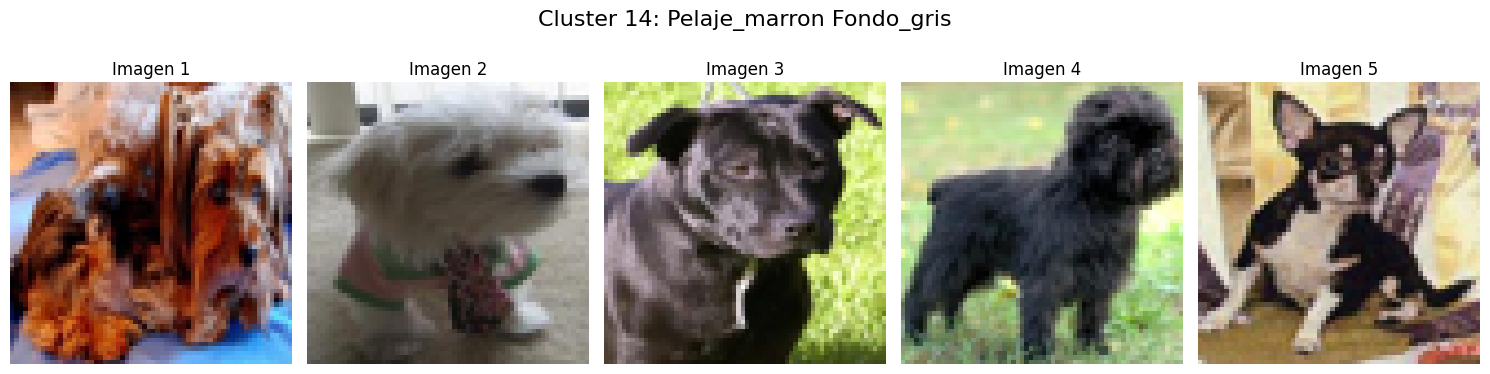

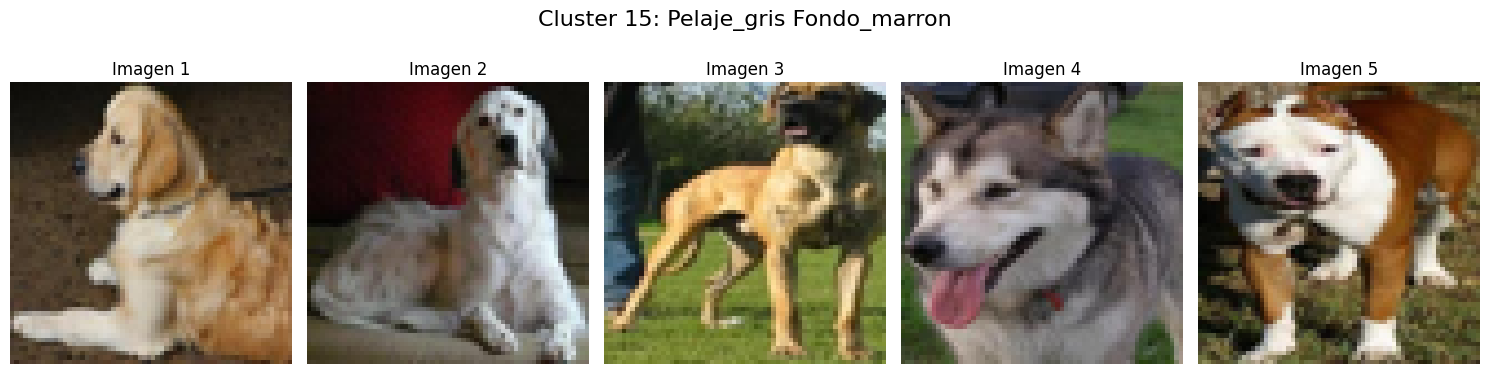

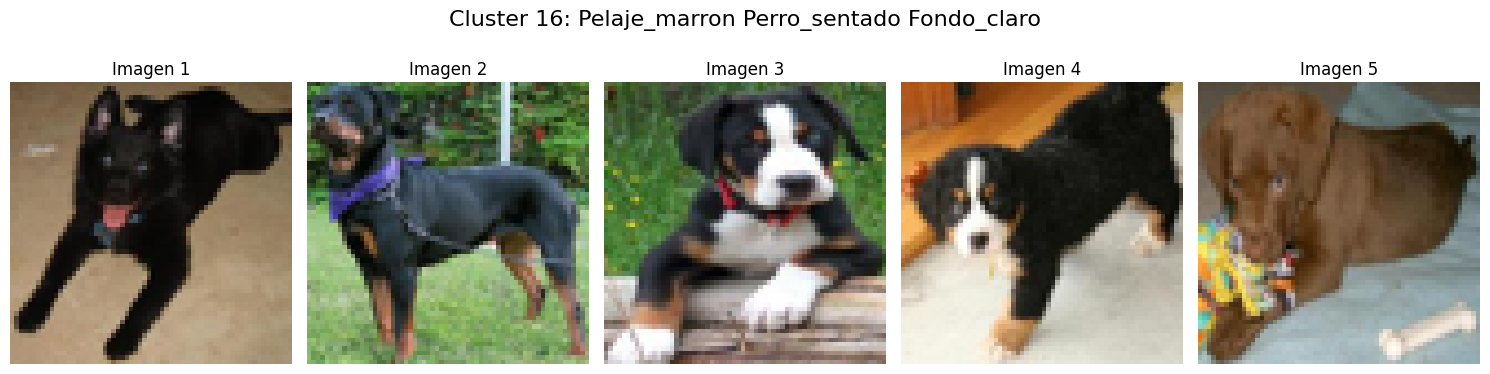

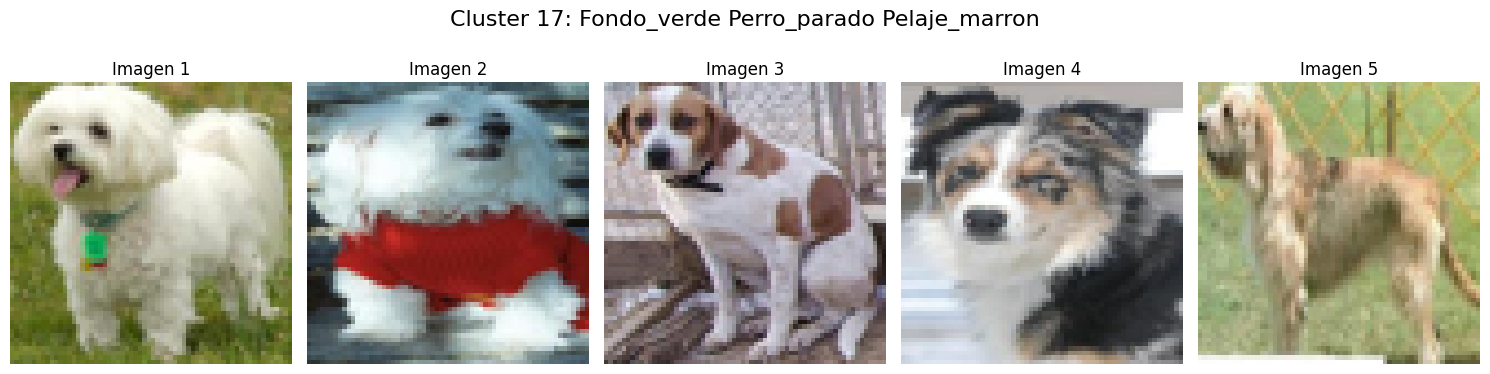

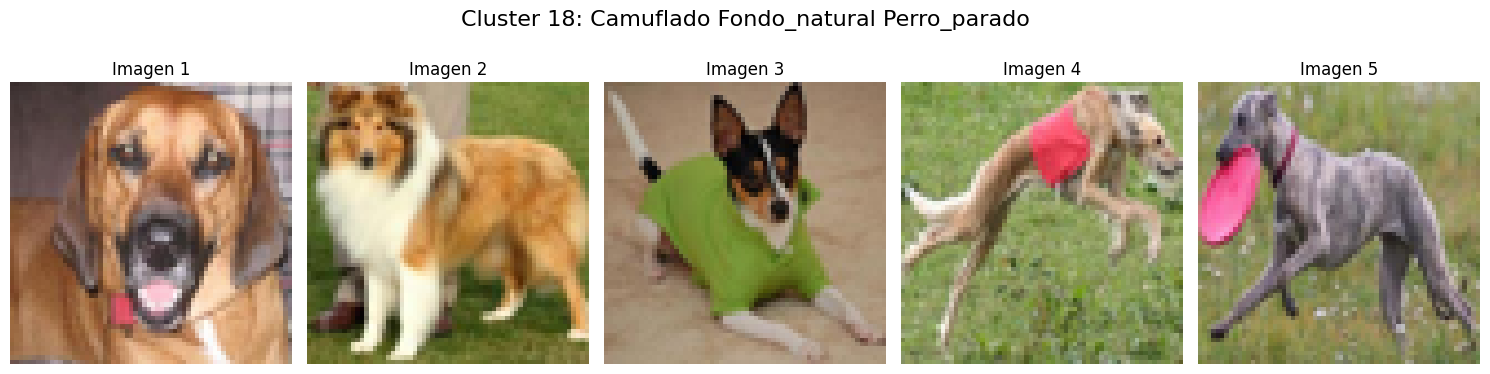

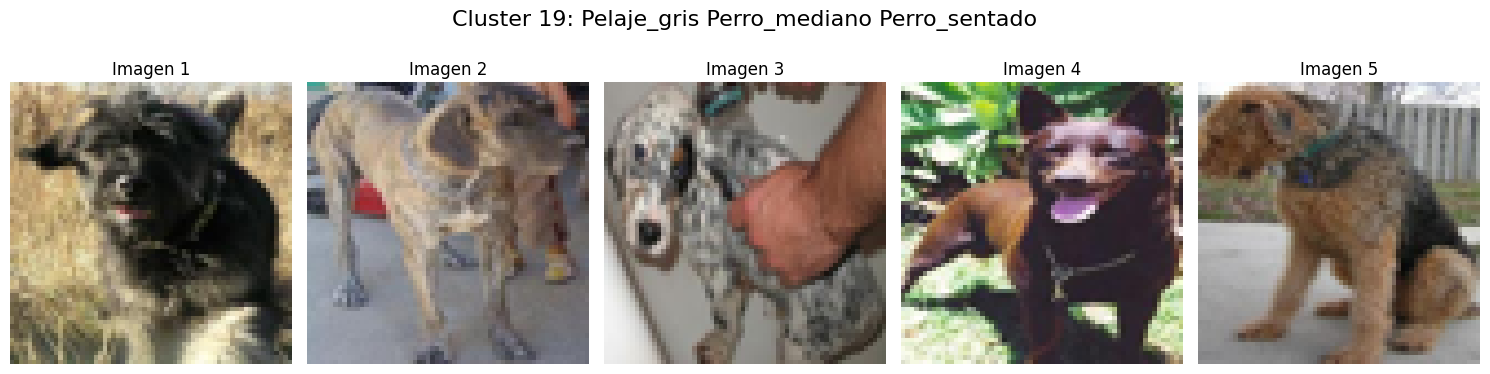

In [44]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Obtener una lista de todos los IDs de cluster únicos
all_cluster_ids = image_df['cluster_label'].unique()

for cluster_id in sorted(all_cluster_ids):
    cluster_images = image_df[image_df['cluster_label'] == cluster_id]

    # Seleccionar hasta 5 imágenes aleatorias de cada cluster para mostrar
    # Usamos random.sample para evitar errores si el número de imágenes es menor que 5
    num_samples = min(5, len(cluster_images))
    if num_samples == 0:
        print(f"No se encontraron imágenes para el Cluster {cluster_id}")
        continue

    sample_images_df = cluster_images.sample(n=num_samples, random_state=42) # Usar random_state para reproducibilidad

    # Crear la figura para las imágenes del cluster
    plt.figure(figsize=(num_samples * 3, 4)) # Ajustar el tamaño de la figura dinámicamente

    # Obtener la descripción del cluster del diccionario
    cluster_desc = cluster_descriptions.get(cluster_id, f"Descripción no encontrada para el Cluster {cluster_id}")
    plt.suptitle(f"Cluster {cluster_id}: {cluster_desc}", fontsize=16)

    for i, row in enumerate(sample_images_df.itertuples()):
        plt.subplot(1, num_samples, i + 1) # Crear una cuadrícula de subplots
        try:
            img = Image.open(row.image_path).convert('RGB')
            img = img.resize((IMG_WIDTH, IMG_HEIGHT)) # Redimensionar a las dimensiones de entrenamiento
            plt.imshow(img)
            plt.title(f"Imagen {i+1}")
            plt.axis('off') # Ocultar los ejes para una mejor visualización
        except Exception as e:
            print(f"Error al cargar la imagen {row.image_path}: {e}")
            plt.title("Error")
            plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para el título principal
    plt.show()

### Entrenando clasificador

In [45]:
# 1. Definir las etiquetas para las imágenes representativas (centroides)
# Como X_representative_digits contiene los 20 centroides, sus etiquetas son los IDs de cluster del 0 al 19.
y_representative_digits = np.arange(k)

print(f"Shape de y_representative_digits: {y_representative_digits.shape}")
display(y_representative_digits)

Shape de y_representative_digits: (20,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [46]:
# 2. Cargar el dataset de prueba (X_test)
X_test = cargar_imagenes(test_dir)

if X_test.shape[0] > 0:
    print(f"Shape final del dataset de prueba cargado: {X_test.shape}")
else:
    print("No se cargaron imágenes de prueba. Verifica la ruta.")

Cargando 8580 imágenes de /content/drive/MyDrive/Colab Notebooks/Datasets/Stanford_dogs_unlabeled/test...
1000 imágenes procesadas.
2000 imágenes procesadas.
3000 imágenes procesadas.
4000 imágenes procesadas.
5000 imágenes procesadas.
6000 imágenes procesadas.
7000 imágenes procesadas.
8000 imágenes procesadas.
Shape final del dataset de prueba cargado: (8580, 12288)


In [47]:
# 3. Obtener las etiquetas para el dataset de prueba (y_test)
# Usaremos el modelo K-Means entrenado para asignar cada imagen de prueba a un cluster.
y_test = kmeans.predict(X_test)

print(f"Shape de y_test: {y_test.shape}")
display(pd.Series(y_test).value_counts().sort_index())

Shape de y_test: (8580,)


,count
0,358
1,362
2,363
3,202
4,666
5,432
6,435
7,388
8,390
9,348


### Entrenamiento y Evaluación del Clasificador

In [49]:
from sklearn.linear_model import LogisticRegression

# Crear y entrenar el clasificador Logistic Regression
log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

# El entrenamiento se realiza con los centroides (X_representative_digits) y sus IDs de cluster (y_representative_digits)
print("Entrenando el clasificador...")
%time log_reg2.fit(X_representative_digits, y_representative_digits)
print("Clasificador entrenado.")

# Evaluar el clasificador utilizando las imágenes de prueba (X_test) y sus etiquetas de cluster asignadas por K-Means (y_test)
score = log_reg2.score(X_test, y_test)
print(f"Precisión del clasificador en el conjunto de prueba: {score:.4f}")

Entrenando el clasificador...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 12.8 s, sys: 15.7 ms, total: 12.8 s
Wall time: 6.63 s
Clasificador entrenado.
Precisión del clasificador en el conjunto de prueba: 0.3613


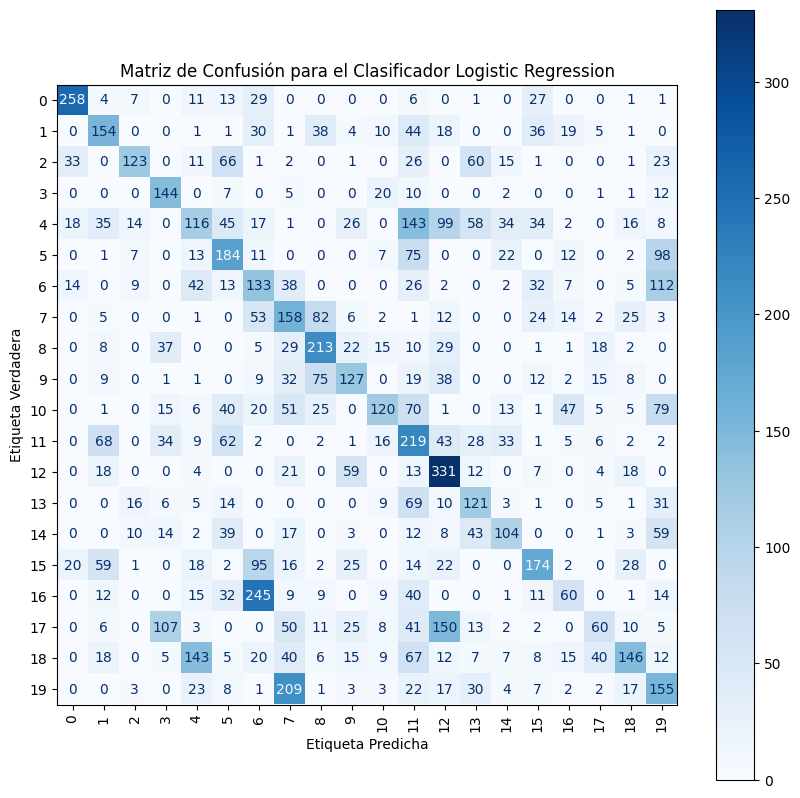

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtener las predicciones del clasificador en el conjunto de prueba
y_pred = log_reg2.predict(X_test)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
fig, ax = plt.subplots(figsize=(10, 10))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(k))
display_cm.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Matriz de Confusión para el Clasificador Logistic Regression')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.grid(False)
plt.show()

## Aprendizaje activo


### Identificación y Visualización de Imágenes Inciertas para Aprendizaje Activo

Este paso utiliza el clasificador actual (`log_reg2`) para identificar las imágenes de entrenamiento sobre las cuales el modelo tiene menor confianza en su predicción.

Confianza del modelo en las 20 imágenes más inciertas (de menor a mayor):
[0.11986789 0.14936479 0.1549719  0.1577069  0.16732791 0.16981023
 0.17105268 0.1717544  0.17338982 0.17427516 0.17512234 0.17993145
 0.18105869 0.18151751 0.18678786 0.18703051 0.18747097 0.18809591
 0.19061477 0.19234169]


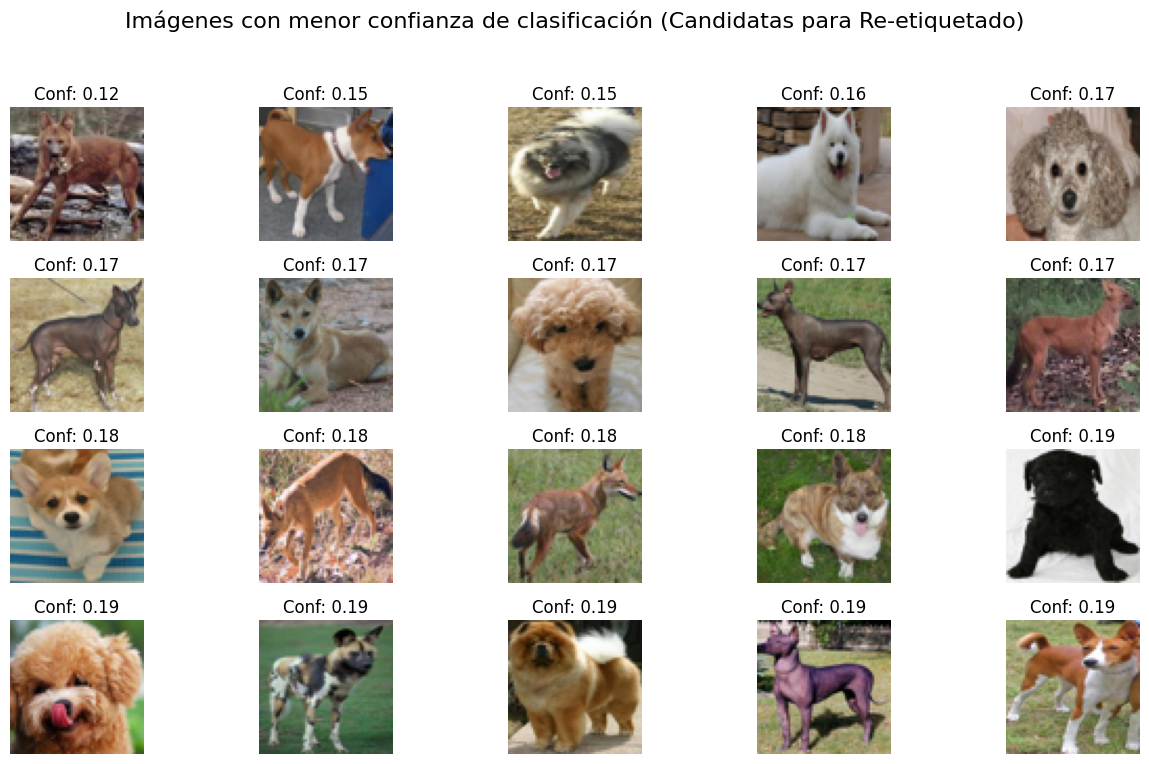

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Usaremos un subconjunto de X_train (los primeros 1000 ejemplos) para esta demostración de aprendizaje activo
X_train_subset = X_train[:1000]

# Obtener las probabilidades de predicción del clasificador actual (log_reg2)
probas = log_reg2.predict_proba(X_train_subset)

# Encontrar la máxima probabilidad para cada muestra (la confianza del modelo en su predicción)
labels_ixs = np.argmax(probas, axis=1) # El índice de la clase con la probabilidad más alta
labels_confidence = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)]) # La probabilidad más alta en sí

# Ordenar los índices de las muestras por su confianza (de menor a mayor)
sorted_ixs = np.argsort(labels_confidence)

# Seleccionar las 'k' muestras menos confiables (donde k es el número de clusters, 20 en este caso)
num_uncertain_samples = k # k global definido como 20
least_confident_indices = sorted_ixs[:num_uncertain_samples]

print("Confianza del modelo en las 20 imágenes más inciertas (de menor a mayor):")
print(labels_confidence[least_confident_indices])

# Visualizar las imágenes con menor confianza
X_lowest = X_train_subset[least_confident_indices]

plt.figure(figsize=(num_uncertain_samples // 5 * 2 + 5, 8)) # Ajustar el tamaño de la figura
for index, img_flat in enumerate(X_lowest):
    plt.subplot(num_uncertain_samples // 5, 5, index + 1) # Crear una cuadrícula de 4 filas x 5 columnas para k=20
    # Reconstruir la imagen a su forma original (IMG_HEIGHT x IMG_WIDTH x 3)
    img_reshaped = img_flat.reshape(IMG_HEIGHT, IMG_WIDTH, 3)
    plt.imshow(img_reshaped)
    plt.title(f"Conf: {labels_confidence[least_confident_indices[index]]:.2f}") # Mostrar la confianza
    plt.axis('off')
plt.suptitle('Imágenes con menor confianza de clasificación (Candidatas para Re-etiquetado)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar el layout para el título principal
plt.show()

### Simulación de Re-etiquetado y Reentrenamiento

En un escenario real de aprendizaje activo, las imágenes visualizadas en el paso anterior serían enviadas a un experto humano para obtener sus etiquetas correctas. Aquí, simularemos este paso utilizando las etiquetas de cluster K-Means existentes para los ejemplos seleccionados y reentrenaremos el modelo.

In [56]:
from sklearn.linear_model import LogisticRegression

# Obtener las etiquetas de cluster K-Means para el subconjunto de entrenamiento inicial
initial_labels_for_subset = cluster_labels[:1000]

# Mostrar las etiquetas actuales (K-Means) de las imágenes menos confiables
print("Etiquetas K-Means asignadas a las 20 imágenes más inciertas (simulando 'y_lowest'):")
y_lowest_kmeans_labels = initial_labels_for_subset[least_confident_indices]
print(y_lowest_kmeans_labels)

# Crear un nuevo conjunto de etiquetas de entrenamiento para el subconjunto
# Esto simula el proceso de "actualizar" las etiquetas para las muestras inciertas.
# En este caso, simplemente mantenemos las etiquetas K-Means existentes para esas muestras.
y_train2 = initial_labels_for_subset.copy()
# La línea siguiente no cambiará las etiquetas si y_lowest_kmeans_labels ya provienen de initial_labels_for_subset,
# pero mantiene la estructura del flujo de aprendizaje activo de 're-etiquetar'.
y_train2[least_confident_indices] = y_lowest_kmeans_labels

# Reentrenar un nuevo clasificador con el subconjunto de entrenamiento y las etiquetas (simuladas) actualizadas
log_reg_active_learning = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

print("\nEntrenando nuevo clasificador con etiquetas 'actualizadas' (simuladas) del subconjunto...")
%time log_reg_active_learning.fit(X_train_subset, y_train2)
print("Clasificador reentrenado.")

# Evaluar el nuevo modelo en el conjunto de prueba original
score_active_learning = log_reg_active_learning.score(X_test, y_test)
print(f"Precisión del clasificador después del paso de aprendizaje activo (simulado): {score_active_learning:.4f}")

Etiquetas K-Means asignadas a las 20 imágenes más inciertas (simulando 'y_lowest'):
[ 4 15 19  7 18 10 18 10 16  4 18 10 18  1 13 12  4 18 18 18]

Entrenando nuevo clasificador con etiquetas 'actualizadas' (simuladas) del subconjunto...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 3min 25s, sys: 324 ms, total: 3min 25s
Wall time: 2min 9s
Clasificador reentrenado.
Precisión del clasificador después del paso de aprendizaje activo (simulado): 0.4205


Se obtiene una mejora con una presicion del 42.05%